# Code Example: DPC Contrast Transfer Function (CTF)

## Overview

This example demonstrates the **Contrast Transfer Function (CTF)** for **Differential Phase Contrast (DPC)** imaging. Understanding the CTF is crucial for interpreting DPC images and understanding their resolution limits.

## Background

### What is the CTF?

The **CTF** describes how different spatial frequencies in the object are transferred to the image:

$$
I(\vec{q}) = \text{CTF}(\vec{q}) \cdot O(\vec{q})
$$

where:
- $I(\vec{q})$ = image in Fourier space
- $O(\vec{q})$ = object in Fourier space  
- $\text{CTF}(\vec{q})$ = contrast transfer function

### DPC Transfer Function

For DPC imaging using center-of-mass (COM) measurements, the transfer function is:

$$
\text{CTF}_{\text{DPC}}(q) = \frac{2\pi q}{\lambda} \cdot A(q)
$$

where:
- $q$ = spatial frequency (1/Å)
- $\lambda$ = electron wavelength
- $A(q)$ = aperture function (depends on detector geometry)

### Key Features

1. **Linear in q**: Low frequencies suppressed, high frequencies enhanced
2. **Differential**: Responds to phase *gradients*, not phase itself
3. **Weak phase approximation**: Valid for thin samples
4. **Aperture dependent**: Shape affects CTF

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.special import j1  # Bessel function

print("DPC Contrast Transfer Function Analysis")
print("=" * 50)

DPC Contrast Transfer Function Analysis


## Part 1: Basic DPC Transfer Function

### Linear CTF

The simplest DPC CTF is linear in spatial frequency:

$$
\text{CTF}_{\text{DPC}}(q) = C \cdot q
$$

where $C = 2\pi/\lambda$ is a constant.

This means:
- **DC (q=0)**: Zero transfer (no response to constant phase)
- **Low q**: Weak transfer (insensitive to slow variations)
- **High q**: Strong transfer (sensitive to sharp features)

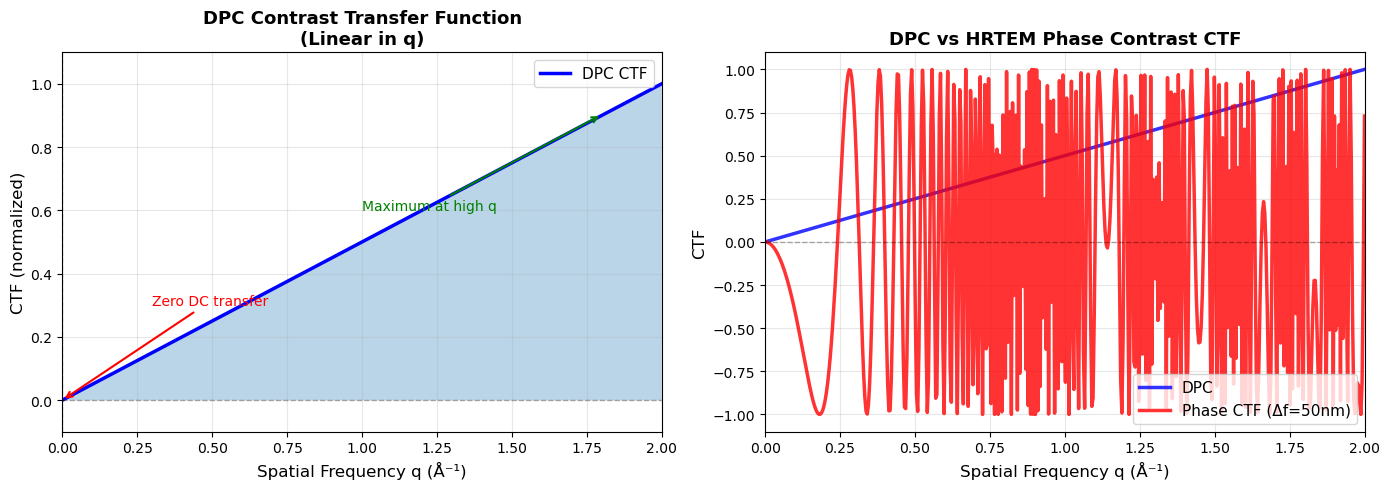


Microscope parameters:
  Energy: 200 keV
  Wavelength: 2.51 pm = 0.0251 Å
  CTF coefficient C = 2π/λ: 250.33 Å

Key differences:
  • DPC: Monotonic, no zero crossings
  • Phase CTF: Oscillatory, multiple zero crossings
  • DPC: Always enhances high frequencies
  • Phase CTF: Can invert contrast at certain q


In [12]:
# Microscope parameters
energy_keV = 200  # Accelerating voltage
wavelength_pm = 2.51  # pm (200 keV)
wavelength_A = wavelength_pm / 100  # Convert to Angstroms

# Spatial frequency range
q_max = 2.0  # Å⁻¹ (typical for atomic resolution)
q = np.linspace(0, q_max, 500)

# DPC CTF (simplified - linear)
C = 2 * np.pi / wavelength_A
CTF_DPC_simple = C * q

# Normalize for visualization
CTF_DPC_simple_norm = CTF_DPC_simple / np.max(CTF_DPC_simple)

# For comparison: conventional phase contrast (HRTEM)
# CTF_phase = -sin(χ(q)) where χ includes defocus and aberrations
defocus_nm = 50  # nm
defocus_A = defocus_nm * 10
Cs_mm = 1.0  # Spherical aberration (mm)
Cs_A = Cs_mm * 1e7  # Convert to Angstroms

# Phase shift function
chi = (np.pi * wavelength_A * q**2 * defocus_A + 
       0.5 * np.pi * Cs_A * wavelength_A**3 * q**4)
CTF_phase = -np.sin(chi)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPC CTF
ax = axes[0]
ax.plot(q, CTF_DPC_simple_norm, 'b-', linewidth=2.5, label='DPC CTF')
ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.3)
ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.3)
ax.fill_between(q, 0, CTF_DPC_simple_norm, alpha=0.3)
ax.set_xlabel('Spatial Frequency q (Å⁻¹)', fontsize=12)
ax.set_ylabel('CTF (normalized)', fontsize=12)
ax.set_title('DPC Contrast Transfer Function\n(Linear in q)', fontsize=13, weight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, q_max)
ax.set_ylim(-0.1, 1.1)

# Add annotations
ax.annotate('Zero DC transfer', xy=(0, 0), xytext=(0.3, 0.3),
           arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
           fontsize=10, color='red')
ax.annotate('Maximum at high q', xy=(q_max*0.9, CTF_DPC_simple_norm[-50]), 
           xytext=(q_max*0.5, 0.6),
           arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
           fontsize=10, color='green')

# Comparison with phase CTF
ax = axes[1]
ax.plot(q, CTF_DPC_simple_norm, 'b-', linewidth=2.5, label='DPC', alpha=0.8)
ax.plot(q, CTF_phase, 'r-', linewidth=2.5, label=f'Phase CTF (Δf={defocus_nm}nm)', alpha=0.8)
ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Spatial Frequency q (Å⁻¹)', fontsize=12)
ax.set_ylabel('CTF', fontsize=12)
ax.set_title('DPC vs HRTEM Phase Contrast CTF', fontsize=13, weight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, q_max)
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

print(f"\nMicroscope parameters:")
print(f"  Energy: {energy_keV} keV")
print(f"  Wavelength: {wavelength_pm} pm = {wavelength_A:.4f} Å")
print(f"  CTF coefficient C = 2π/λ: {C:.2f} Å")
print(f"\nKey differences:")
print(f"  • DPC: Monotonic, no zero crossings")
print(f"  • Phase CTF: Oscillatory, multiple zero crossings")
print(f"  • DPC: Always enhances high frequencies")
print(f"  • Phase CTF: Can invert contrast at certain q")

## Part 2: Effect of Aperture/Detector Geometry

### Aperture Function

The detector geometry modifies the CTF through an **aperture function** $A(q)$:

**Circular detector (radius R):**
$$
A(q) = \text{circ}\left(\frac{q}{q_{\max}}\right)
$$

**Segmented detector (split detector for DPC):**
$$
A(q) = \text{asymmetric depending on segment}
$$

**Finite collection angle:**
$$
A(q) = \frac{2J_1(\pi q R)}{\pi q R}
$$

where $J_1$ is the first-order Bessel function.

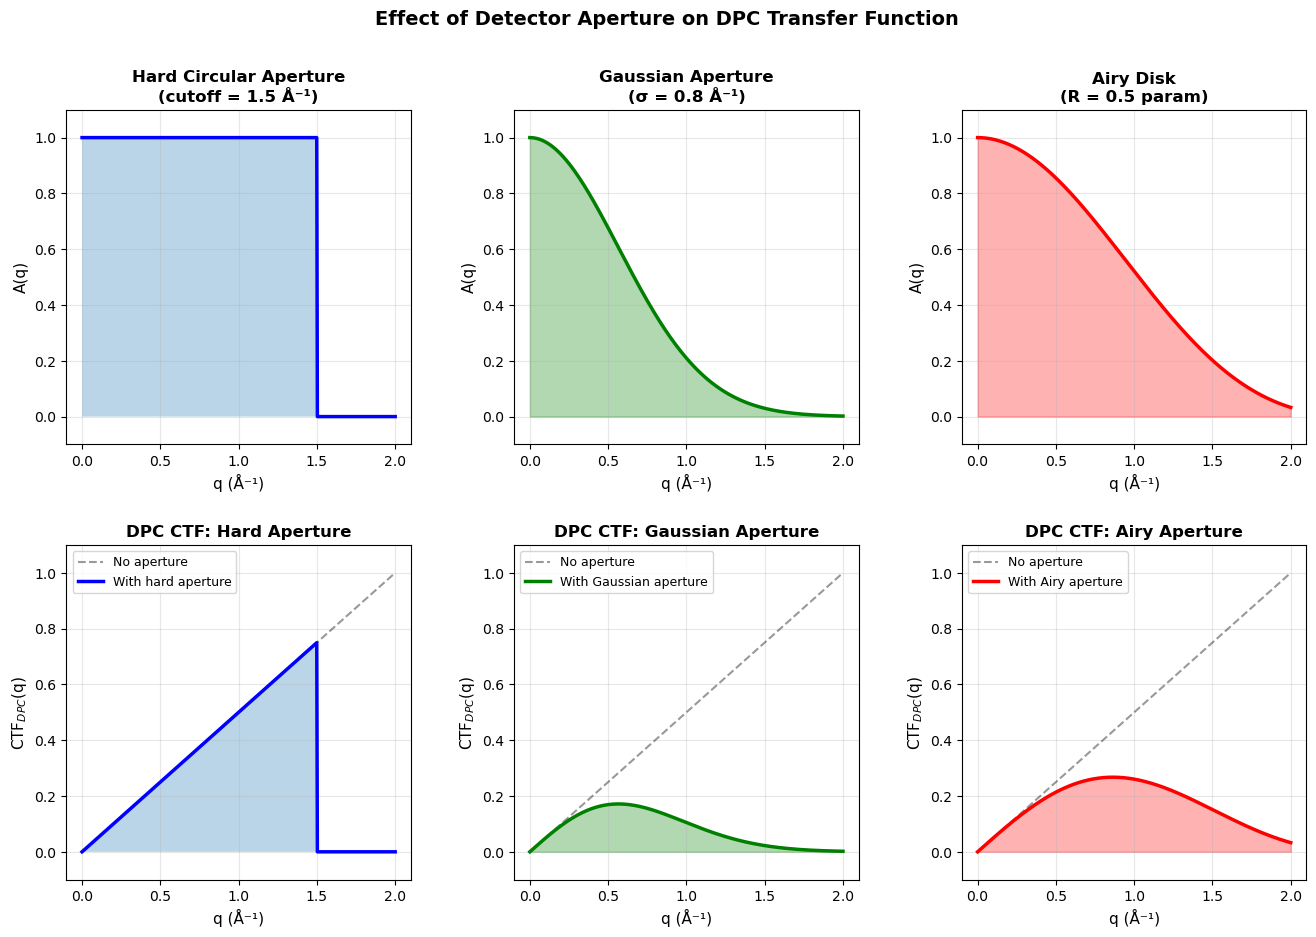


Aperture effects:
  • Hard cutoff: Abrupt frequency limit at q = 1.5 Å⁻¹
  • Gaussian: Smooth rolloff, more realistic
  • Airy: Oscillations from diffraction, side lobes

Physical interpretation:
  • Aperture limits maximum spatial frequency
  • Affects resolution: Δr ≈ 1/q_cutoff
  • Smooth apertures reduce ringing artifacts


In [4]:
# Define different aperture functions

# 1. Circular aperture (hard edge)
q_cutoff = 1.5  # Å⁻¹
aperture_hard = np.where(q < q_cutoff, 1.0, 0.0)

# 2. Gaussian aperture (soft edge - more realistic)
q_sigma = 0.8  # Å⁻¹
aperture_gaussian = np.exp(-(q / q_sigma)**2)

# 3. Airy disk (diffraction-limited aperture)
# A(q) = [2*J1(x)/x]² where x = π*q*R
R_aperture = 0.5  # Effective radius parameter
x = np.pi * q * R_aperture
x[0] = 1e-10  # Avoid division by zero
aperture_airy = (2 * j1(x) / x)**2
aperture_airy[0] = 1.0  # Correct the DC value

# Apply apertures to DPC CTF
CTF_hard = CTF_DPC_simple_norm * aperture_hard
CTF_gaussian = CTF_DPC_simple_norm * aperture_gaussian
CTF_airy = CTF_DPC_simple_norm * aperture_airy

# Visualize
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Top row: Aperture functions
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(q, aperture_hard, 'b-', linewidth=2.5, label='Hard edge')
ax1.fill_between(q, 0, aperture_hard, alpha=0.3)
ax1.set_xlabel('q (Å⁻¹)', fontsize=11)
ax1.set_ylabel('A(q)', fontsize=11)
ax1.set_title(f'Hard Circular Aperture\n(cutoff = {q_cutoff} Å⁻¹)', 
             fontsize=12, weight='bold')
ax1.grid(alpha=0.3)
ax1.set_ylim(-0.1, 1.1)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(q, aperture_gaussian, 'g-', linewidth=2.5, label='Gaussian')
ax2.fill_between(q, 0, aperture_gaussian, alpha=0.3, color='green')
ax2.set_xlabel('q (Å⁻¹)', fontsize=11)
ax2.set_ylabel('A(q)', fontsize=11)
ax2.set_title(f'Gaussian Aperture\n(σ = {q_sigma} Å⁻¹)', 
             fontsize=12, weight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim(-0.1, 1.1)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(q, aperture_airy, 'r-', linewidth=2.5, label='Airy')
ax3.fill_between(q, 0, aperture_airy, alpha=0.3, color='red')
ax3.set_xlabel('q (Å⁻¹)', fontsize=11)
ax3.set_ylabel('A(q)', fontsize=11)
ax3.set_title(f'Airy Disk\n(R = {R_aperture} param)', 
             fontsize=12, weight='bold')
ax3.grid(alpha=0.3)
ax3.set_ylim(-0.1, 1.1)

# Bottom row: DPC CTF with apertures
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(q, CTF_DPC_simple_norm, 'k--', linewidth=1.5, alpha=0.4, label='No aperture')
ax4.plot(q, CTF_hard, 'b-', linewidth=2.5, label='With hard aperture')
ax4.fill_between(q, 0, CTF_hard, alpha=0.3)
ax4.set_xlabel('q (Å⁻¹)', fontsize=11)
ax4.set_ylabel('CTF$_{DPC}$(q)', fontsize=11)
ax4.set_title('DPC CTF: Hard Aperture', fontsize=12, weight='bold')
ax4.grid(alpha=0.3)
ax4.legend(fontsize=9)
ax4.set_ylim(-0.1, 1.1)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(q, CTF_DPC_simple_norm, 'k--', linewidth=1.5, alpha=0.4, label='No aperture')
ax5.plot(q, CTF_gaussian, 'g-', linewidth=2.5, label='With Gaussian aperture')
ax5.fill_between(q, 0, CTF_gaussian, alpha=0.3, color='green')
ax5.set_xlabel('q (Å⁻¹)', fontsize=11)
ax5.set_ylabel('CTF$_{DPC}$(q)', fontsize=11)
ax5.set_title('DPC CTF: Gaussian Aperture', fontsize=12, weight='bold')
ax5.grid(alpha=0.3)
ax5.legend(fontsize=9)
ax5.set_ylim(-0.1, 1.1)

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(q, CTF_DPC_simple_norm, 'k--', linewidth=1.5, alpha=0.4, label='No aperture')
ax6.plot(q, CTF_airy, 'r-', linewidth=2.5, label='With Airy aperture')
ax6.fill_between(q, 0, CTF_airy, alpha=0.3, color='red')
ax6.set_xlabel('q (Å⁻¹)', fontsize=11)
ax6.set_ylabel('CTF$_{DPC}$(q)', fontsize=11)
ax6.set_title('DPC CTF: Airy Aperture', fontsize=12, weight='bold')
ax6.grid(alpha=0.3)
ax6.legend(fontsize=9)
ax6.set_ylim(-0.1, 1.1)

plt.suptitle('Effect of Detector Aperture on DPC Transfer Function', 
            fontsize=14, weight='bold')
plt.show()

print("\nAperture effects:")
print(f"  • Hard cutoff: Abrupt frequency limit at q = {q_cutoff} Å⁻¹")
print(f"  • Gaussian: Smooth rolloff, more realistic")
print(f"  • Airy: Oscillations from diffraction, side lobes")
print(f"\nPhysical interpretation:")
print(f"  • Aperture limits maximum spatial frequency")
print(f"  • Affects resolution: Δr ≈ 1/q_cutoff")
print(f"  • Smooth apertures reduce ringing artifacts")

## Part 3: 2D DPC Transfer Function

### Radially Symmetric CTF

For isotropic imaging:
$$
\text{CTF}_{\text{DPC}}(q_x, q_y) = C \sqrt{q_x^2 + q_y^2}
$$

### Directional DPC (Split Detector)

For segmented detectors (e.g., quadrant detector):
$$
\text{CTF}_{x}(q_x, q_y) \propto q_x
$$
$$
\text{CTF}_{y}(q_x, q_y) \propto q_y
$$

These are **directional**: sensitive to gradients along specific axes.

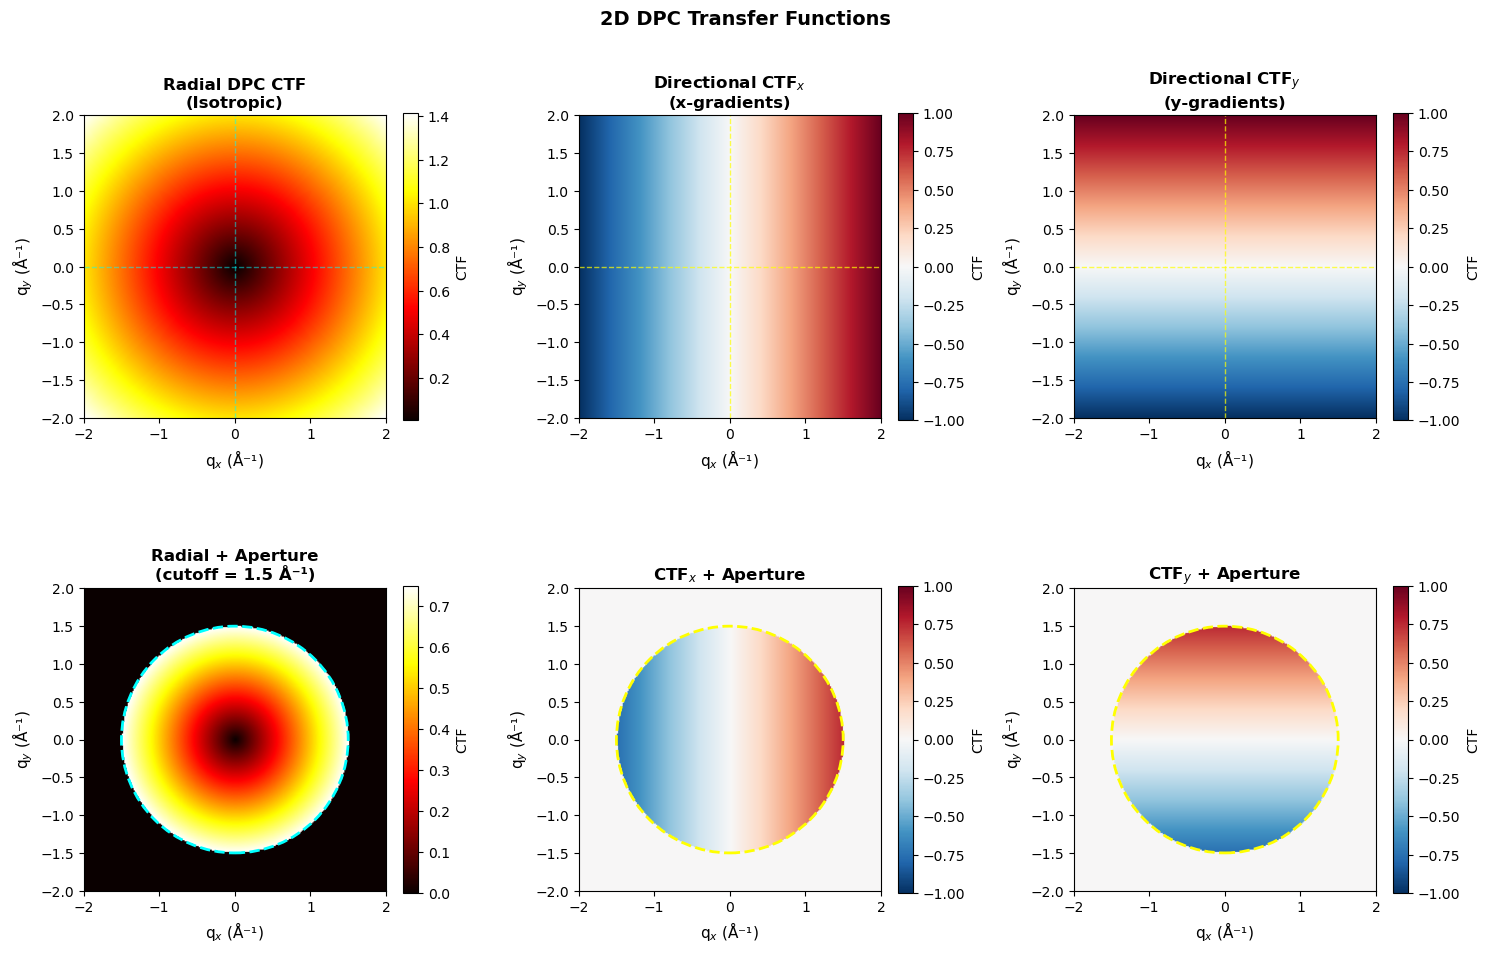


2D CTF characteristics:
  • Radial: Same in all directions, cone-shaped
  • CTF_x: Positive for +q_x, negative for -q_x (bipolar)
  • CTF_y: Positive for +q_y, negative for -q_y (bipolar)
  • Aperture: Restricts to circular region in Fourier space


In [5]:
# Create 2D spatial frequency grid
N = 256
q_2d_max = 2.0  # Å⁻¹
qx = np.linspace(-q_2d_max, q_2d_max, N)
qy = np.linspace(-q_2d_max, q_2d_max, N)
QX, QY = np.meshgrid(qx, qy)
Q_mag = np.sqrt(QX**2 + QY**2)

# 1. Radially symmetric DPC CTF
CTF_2D_radial = Q_mag / q_2d_max  # Normalized

# 2. Directional CTFs (x and y components)
CTF_2D_x = QX / q_2d_max  # Sensitive to x-gradients
CTF_2D_y = QY / q_2d_max  # Sensitive to y-gradients

# 3. Apply circular aperture
aperture_2d = np.where(Q_mag < q_cutoff, 1.0, 0.0)
CTF_2D_radial_aperture = CTF_2D_radial * aperture_2d
CTF_2D_x_aperture = CTF_2D_x * aperture_2d
CTF_2D_y_aperture = CTF_2D_y * aperture_2d

# Visualize 2D CTFs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Radial CTF (no aperture)
ax = axes[0, 0]
im = ax.imshow(CTF_2D_radial, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='hot', interpolation='bilinear', origin='lower')
ax.axhline(0, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title('Radial DPC CTF\n(Isotropic)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

# Directional CTF_x
ax = axes[0, 1]
im = ax.imshow(CTF_2D_x, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='RdBu_r', interpolation='bilinear', origin='lower', vmin=-1, vmax=1)
ax.axhline(0, color='yellow', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0, color='yellow', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title('Directional CTF$_x$\n(x-gradients)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

# Directional CTF_y
ax = axes[0, 2]
im = ax.imshow(CTF_2D_y, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='RdBu_r', interpolation='bilinear', origin='lower', vmin=-1, vmax=1)
ax.axhline(0, color='yellow', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0, color='yellow', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title('Directional CTF$_y$\n(y-gradients)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

# With aperture
ax = axes[1, 0]
im = ax.imshow(CTF_2D_radial_aperture, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='hot', interpolation='bilinear', origin='lower')
# Draw aperture circle
circle = plt.Circle((0, 0), q_cutoff, fill=False, color='cyan', linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title(f'Radial + Aperture\n(cutoff = {q_cutoff} Å⁻¹)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

ax = axes[1, 1]
im = ax.imshow(CTF_2D_x_aperture, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='RdBu_r', interpolation='bilinear', origin='lower', vmin=-1, vmax=1)
circle = plt.Circle((0, 0), q_cutoff, fill=False, color='yellow', linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title('CTF$_x$ + Aperture', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

ax = axes[1, 2]
im = ax.imshow(CTF_2D_y_aperture, extent=[-q_2d_max, q_2d_max, -q_2d_max, q_2d_max],
              cmap='RdBu_r', interpolation='bilinear', origin='lower', vmin=-1, vmax=1)
circle = plt.Circle((0, 0), q_cutoff, fill=False, color='yellow', linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.set_xlabel('q$_x$ (Å⁻¹)', fontsize=11)
ax.set_ylabel('q$_y$ (Å⁻¹)', fontsize=11)
ax.set_title('CTF$_y$ + Aperture', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='CTF')

plt.suptitle('2D DPC Transfer Functions', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n2D CTF characteristics:")
print("  • Radial: Same in all directions, cone-shaped")
print("  • CTF_x: Positive for +q_x, negative for -q_x (bipolar)")
print("  • CTF_y: Positive for +q_y, negative for -q_y (bipolar)")
print("  • Aperture: Restricts to circular region in Fourier space")

## Part 4: Resolution and Information Limit

### Resolution Criteria

**Rayleigh criterion:**
$$
d_{\min} = \frac{0.61 \lambda}{\alpha}
$$

where $\alpha$ is the collection angle.

**Information limit:**
$$
q_{\max} = \frac{2\alpha}{\lambda}
$$

### DPC Resolution

DPC resolution is limited by:
1. **Detector geometry** (aperture cutoff)
2. **Beam coherence** (temporal and spatial)
3. **Noise** (shot noise, detector noise)
4. **Sample motion** (drift, vibration)

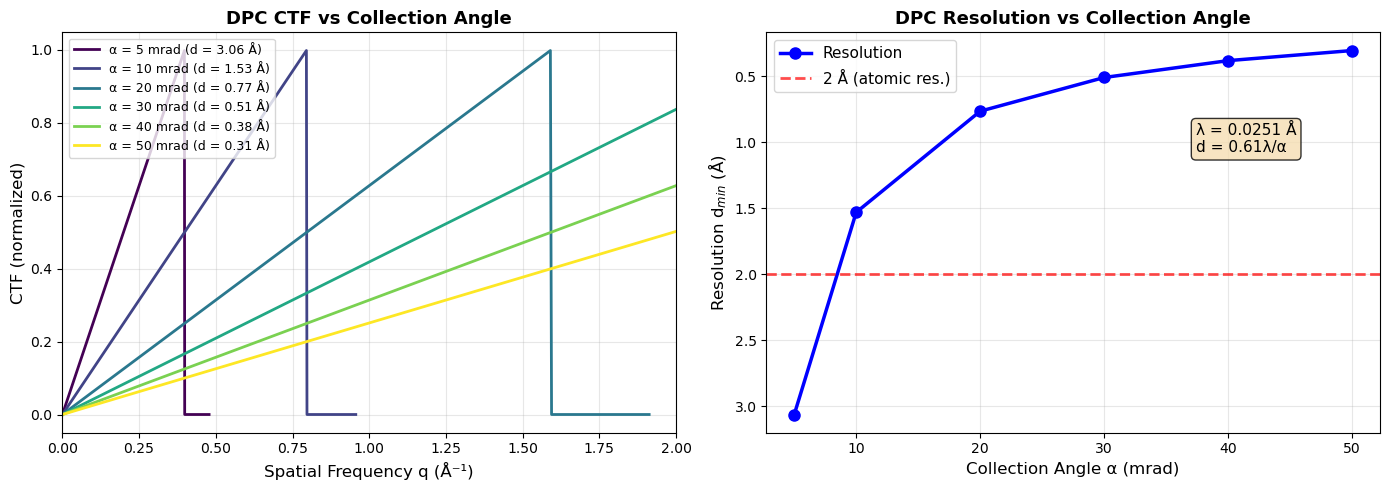


Resolution vs Collection Angle:
α (mrad)     d_min (Å)    q_limit (Å⁻¹)  
----------------------------------------
5.0          3.06         0.398          
10.0         1.53         0.797          
20.0         0.77         1.594          
30.0         0.51         2.390          
40.0         0.38         3.187          
50.0         0.31         3.984          

To achieve atomic resolution (d < 2 Å):
  Need α > 7.7 mrad


In [6]:
# Calculate resolution for different collection angles

# Collection angles (mrad)
alpha_mrad = np.array([5, 10, 20, 30, 40, 50])  # mrad
alpha_rad = alpha_mrad * 1e-3  # Convert to radians

# Wavelength
lambda_A = wavelength_A  # Angstroms

# Calculate resolution (Rayleigh criterion)
d_min_A = 0.61 * lambda_A / alpha_rad  # Angstroms

# Information limit
q_info_limit = 2 * alpha_rad / lambda_A  # Å⁻¹

# Calculate CTF for each angle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CTFs with different cutoffs
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(alpha_mrad)))

for i, (alpha, q_lim, color) in enumerate(zip(alpha_mrad, q_info_limit, colors)):
    # CTF with this aperture
    q_local = np.linspace(0, min(q_max, q_lim * 1.2), 500)
    CTF_local = q_local / q_lim  # Normalized to this limit
    aperture_local = np.where(q_local < q_lim, 1.0, 0.0)
    CTF_with_aperture = CTF_local * aperture_local
    
    ax.plot(q_local, CTF_with_aperture, linewidth=2, color=color, 
           label=f'α = {alpha} mrad (d = {d_min_A[i]:.2f} Å)')

ax.set_xlabel('Spatial Frequency q (Å⁻¹)', fontsize=12)
ax.set_ylabel('CTF (normalized)', fontsize=12)
ax.set_title('DPC CTF vs Collection Angle', fontsize=13, weight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, q_max)

# Resolution vs collection angle
ax = axes[1]
ax.plot(alpha_mrad, d_min_A, 'o-', linewidth=2.5, markersize=8, color='blue', label='Resolution')
ax.set_xlabel('Collection Angle α (mrad)', fontsize=12)
ax.set_ylabel('Resolution d$_{min}$ (Å)', fontsize=12)
ax.set_title('DPC Resolution vs Collection Angle', fontsize=13, weight='bold')
ax.grid(alpha=0.3)
ax.invert_yaxis()  # Smaller d is better

# Add atomic resolution reference
ax.axhline(2.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='2 Å (atomic res.)')
ax.legend(fontsize=11)

# Add text box with info
info_text = f"λ = {wavelength_A:.4f} Å\nd = 0.61λ/α"
ax.text(0.7, 0.7, info_text, transform=ax.transAxes, fontsize=11,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nResolution vs Collection Angle:")
print(f"{'α (mrad)':<12} {'d_min (Å)':<12} {'q_limit (Å⁻¹)':<15}")
print("-" * 40)
for i in range(len(alpha_mrad)):
    print(f"{alpha_mrad[i]:<12.1f} {d_min_A[i]:<12.2f} {q_info_limit[i]:<15.3f}")

print(f"\nTo achieve atomic resolution (d < 2 Å):")
alpha_needed = 0.61 * wavelength_A / 2.0  # radians
alpha_needed_mrad = alpha_needed * 1000
print(f"  Need α > {alpha_needed_mrad:.1f} mrad")

## Part 5: Practical Example - Simulating DPC Image Formation

Let's simulate how a test object is transferred through the DPC CTF.

### Test Object: Phase Step

Create a simple phase object with a step:
$$
\phi(x) = \begin{cases} 0 & x < 0 \\ \phi_0 & x \geq 0 \end{cases}
$$

The phase gradient is:
$$
\frac{d\phi}{dx} = \phi_0 \delta(x)
$$

DPC should show a peak at the edge!

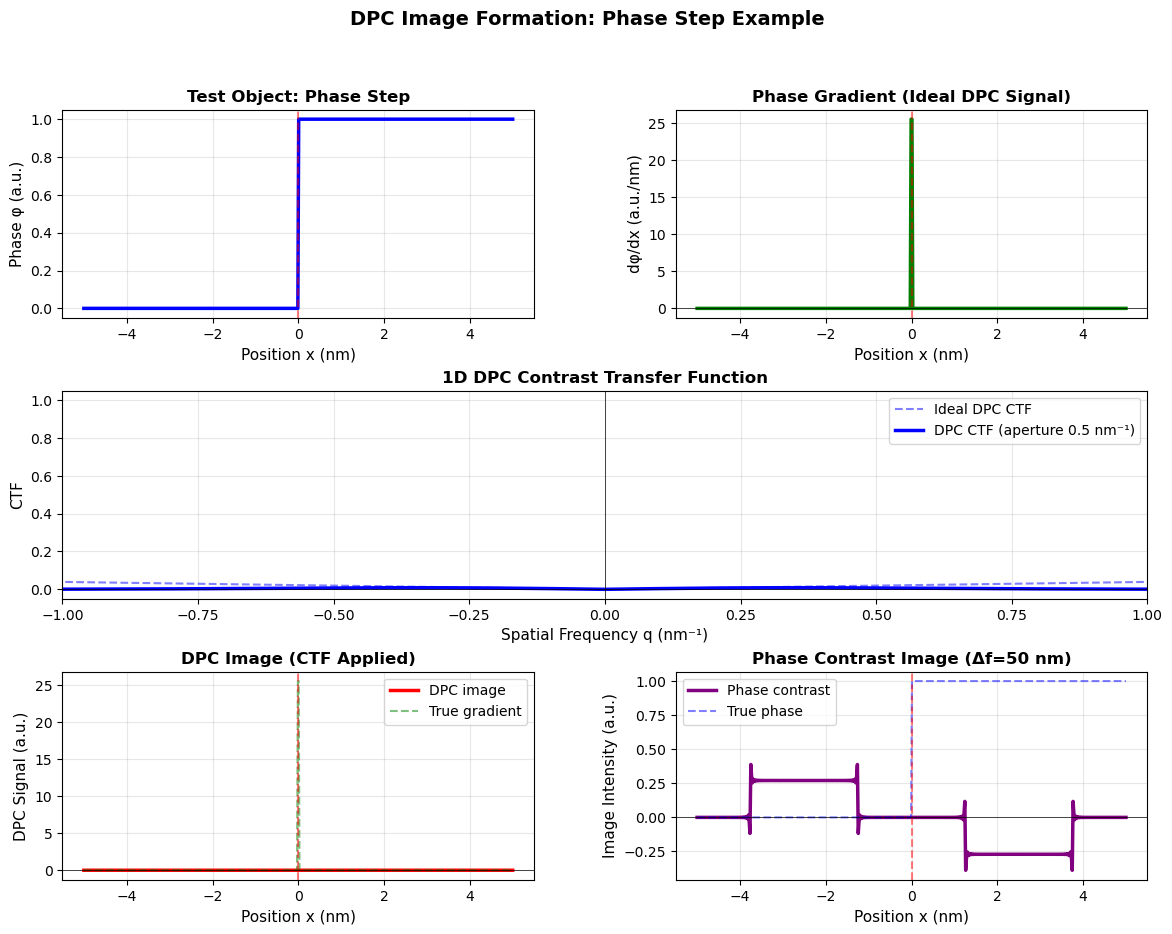


Key observations:
  • DPC signal peaks at the phase discontinuity (edge)
  • Aperture broadens the DPC peak (finite resolution)
  • DPC gives phase *gradient*, not phase itself
  • Phase contrast shows oscillations (CTF zeros)
  • DPC is monotonic - no contrast reversals!


In [7]:
# Create test phase object
N_sim = 512
x_range = 10  # nm
x = np.linspace(-x_range/2, x_range/2, N_sim)
dx = x[1] - x[0]

# Phase step
phase_step = np.zeros(N_sim)
phase_step[N_sim//2:] = 1.0  # Arbitrary phase units

# Phase gradient (numerical derivative)
phase_gradient = np.gradient(phase_step, dx)

# Fourier transform
phase_fft = np.fft.fft(phase_step)
gradient_fft = np.fft.fft(phase_gradient)

# Frequency axis
freq = np.fft.fftfreq(N_sim, dx)  # 1/nm
freq_shifted = np.fft.fftshift(freq)

# DPC CTF (1D)
# CTF_DPC(q) = C * |q|
q_1d = np.abs(freq)
CTF_1D = q_1d / np.max(q_1d[q_1d < np.inf])  # Normalized

# Apply aperture (smooth cutoff)
q_cutoff_1d = 0.5  # 1/nm
aperture_1d = np.exp(-(q_1d / q_cutoff_1d)**2)
CTF_1D_aperture = CTF_1D * aperture_1d

# DPC image = phase gradient convolved with CTF
# In Fourier space: multiplication
DPC_signal_fft = gradient_fft * CTF_1D_aperture
DPC_signal = np.real(np.fft.ifft(DPC_signal_fft))

# Also show conventional phase contrast (for comparison)
# Phase CTF has oscillations
defocus_sim = 50  # nm
chi_1d = np.pi * wavelength_A/10 * (freq * 10)**2 * defocus_sim  # Convert units
CTF_phase_1d = -np.sin(chi_1d)
phase_image_fft = phase_fft * CTF_phase_1d
phase_image = np.real(np.fft.ifft(phase_image_fft))

# Visualize
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# Object: phase
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, phase_step, 'b-', linewidth=2.5)
ax1.set_xlabel('Position x (nm)', fontsize=11)
ax1.set_ylabel('Phase φ (a.u.)', fontsize=11)
ax1.set_title('Test Object: Phase Step', fontsize=12, weight='bold')
ax1.grid(alpha=0.3)
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)

# Object: phase gradient
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x, phase_gradient, 'g-', linewidth=2.5)
ax2.set_xlabel('Position x (nm)', fontsize=11)
ax2.set_ylabel('dφ/dx (a.u./nm)', fontsize=11)
ax2.set_title('Phase Gradient (Ideal DPC Signal)', fontsize=12, weight='bold')
ax2.grid(alpha=0.3)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5)

# CTF
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(freq_shifted, np.fft.fftshift(CTF_1D), 'b--', linewidth=1.5, 
        alpha=0.5, label='Ideal DPC CTF')
ax3.plot(freq_shifted, np.fft.fftshift(CTF_1D_aperture), 'b-', linewidth=2.5, 
        label=f'DPC CTF (aperture {q_cutoff_1d} nm⁻¹)')
ax3.set_xlabel('Spatial Frequency q (nm⁻¹)', fontsize=11)
ax3.set_ylabel('CTF', fontsize=11)
ax3.set_title('1D DPC Contrast Transfer Function', fontsize=12, weight='bold')
ax3.grid(alpha=0.3)
ax3.legend(fontsize=10)
ax3.set_xlim(-1, 1)
ax3.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax3.axhline(0, color='k', linestyle='-', linewidth=0.5)

# DPC image
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(x, DPC_signal, 'r-', linewidth=2.5, label='DPC image')
ax4.plot(x, phase_gradient, 'g--', linewidth=1.5, alpha=0.5, label='True gradient')
ax4.set_xlabel('Position x (nm)', fontsize=11)
ax4.set_ylabel('DPC Signal (a.u.)', fontsize=11)
ax4.set_title('DPC Image (CTF Applied)', fontsize=12, weight='bold')
ax4.grid(alpha=0.3)
ax4.legend(fontsize=10)
ax4.axvline(0, color='red', linestyle='--', alpha=0.5)
ax4.axhline(0, color='k', linestyle='-', linewidth=0.5)

# Phase contrast image (for comparison)
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(x, phase_image, 'purple', linewidth=2.5, label='Phase contrast')
ax5.plot(x, phase_step, 'b--', linewidth=1.5, alpha=0.5, label='True phase')
ax5.set_xlabel('Position x (nm)', fontsize=11)
ax5.set_ylabel('Image Intensity (a.u.)', fontsize=11)
ax5.set_title(f'Phase Contrast Image (Δf={defocus_sim} nm)', fontsize=12, weight='bold')
ax5.grid(alpha=0.3)
ax5.legend(fontsize=10)
ax5.axvline(0, color='red', linestyle='--', alpha=0.5)
ax5.axhline(0, color='k', linestyle='-', linewidth=0.5)

plt.suptitle('DPC Image Formation: Phase Step Example', fontsize=14, weight='bold')
plt.show()

print("\nKey observations:")
print("  • DPC signal peaks at the phase discontinuity (edge)")
print("  • Aperture broadens the DPC peak (finite resolution)")
print("  • DPC gives phase *gradient*, not phase itself")
print("  • Phase contrast shows oscillations (CTF zeros)")
print("  • DPC is monotonic - no contrast reversals!")